In [219]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from unsflow.utils.thesis_plots import *
import re

In [220]:

input_filenames = [
        "../Level_04_implicit/Volume_CSV/results.csv",
        "../Level_03_implicit/Volume_CSV/results.csv",
        "../Level_02_implicit/Volume_CSV/results.csv",
        ]

labels = [
        r'89x41',
        r'177x81',
        r'353x161'
]
lstyles = [
        '--',
        '-.',
        ':',
]


In [221]:
# reference quantities
p_ref = 101325
T_ref = 300
Rair = 287.06
gamma = 1.4
M_ref = 0.2
rho_ref = p_ref / (Rair * T_ref)
a_ref = np.sqrt(gamma * Rair * T_ref)
q_ref = 0.5 * rho_ref * a_ref**2 * M_ref**2

nu_ref = 1.84e-5
mu_ref = nu_ref * rho_ref

In [222]:
datas = {}

for ii,input_filename in enumerate(input_filenames):
    with open(input_filename, 'r') as f:
            ni = int(f.readline().strip().split('=')[1])
            nj = int(f.readline().strip().split('=')[1])
            nk = int(f.readline().strip().split('=')[1])
        
    df = pd.read_csv(input_filename, skiprows=3)
    data = {col: df[col].to_numpy().reshape((ni, nj, nk)) for col in df.columns}
    datas[ii] = data

In [223]:
# open nasa files
nasa_cp = np.loadtxt('../reference/cp_bump.dat', skiprows=2)
nasa_cf = np.loadtxt('../reference/cf_bump.dat', skiprows=2)

In [224]:
def compute_cp(p):
    return (p-p_ref) / q_ref

def compute_cf(tau_x):
    return tau_x / q_ref

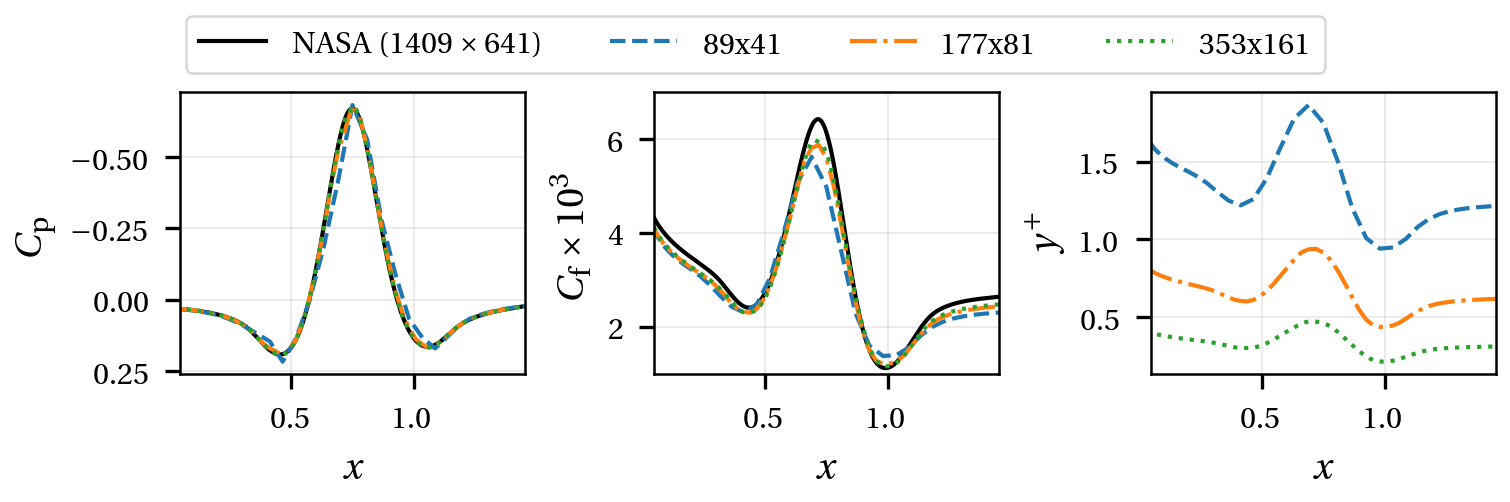

In [225]:
xmin = 0.03
xmax = 1.47


set_thesis_style()
fig, ax = create_figure(fraction=1.0, aspect_ratio=1.0, subplots=(1, 3))

ax[0].plot(nasa_cp[:, 0], nasa_cp[:, 1], label=r"NASA ($1409 \times 641$)", color='k')
ax[1].plot(nasa_cf[:, 0], nasa_cf[:, 1]*1e3, color='k')

for key, data in datas.items():
    mask = (data['x'][:, 0, 0] > xmin) & (data['x'][:, 0, 0] < xmax)
    idx = np.where(mask)[0]

    p = data['Pressure'][idx, 0, 0]
    x = data['x'][idx, 0, 0]
    tau_x = data['Wall Shear Stress X'][idx, 0, 0]
    tau_y = data['Wall Shear Stress Y'][idx, 0, 0]
    tau = np.sqrt(tau_x**2 + tau_y**2)
    yplus = data['Y Plus'][idx, 0, 0]
    
    ax[0].plot(x, compute_cp(p), lstyles[key], mfc='none',label=labels[key])
    ax[1].plot(x, compute_cf(tau)*1e3, lstyles[key])
    ax[2].plot(x, yplus, lstyles[key])


fig.legend(ncol=len(input_filenames)+1, loc='outside upper center')
ax[0].invert_yaxis()
ax[0].set_ylabel(r'$C_{\rm p}$')
ax[0].set_xlabel(r'$x$')
ax[0].grid(alpha=0.3)
ax[0].set_xlim(0.05, 1.45)

ax[1].set_ylabel(r'$C_{\rm f} \times 10^3$')
ax[1].set_xlabel(r'$x$')
ax[1].grid(alpha=0.3)
ax[1].set_ylim(1, 7)
ax[1].set_xlim(0.05, 1.45)

ax[2].set_ylabel(r'$y^+$')
ax[2].set_xlabel(r'$x$')
ax[2].grid(alpha=0.3)
ax[2].set_xlim(0.05, 1.45)

fig.savefig('nasa_bump_comparison.pdf')


In [226]:
# read nasa tecplot file for the viscosity
def read_tecplot(filename):
    """Read a Tecplot ASCII ordered zone (BLOCK or POINT packing).

    Returns
    -------
    variables : list[str]            variable names, in file order
    dims      : tuple(I, J, K)       zone dimensions
    fields    : dict[str, ndarray]   each variable as a 2D array of shape (J, I)
                                     (assumes K == 1, the 2D contour case)
    """
    with open(filename, "r") as f:
        text = f.read()

    # --- variable names: grab every quoted token between VARIABLES and ZONE ---
    header = text.split("ZONE")[0]
    m = re.search(r"VARIABLES\s*=(.*)", header, re.DOTALL)
    variables = re.findall(r'"([^"]*)"', m.group(1)) if m else []

    # --- dimensions (I varies fastest, then J, then K in Tecplot ordered data) ---
    I = int(re.search(r"\bI\s*=\s*(\d+)", text).group(1))
    J = int(re.search(r"\bJ\s*=\s*(\d+)", text).group(1))
    km = re.search(r"\bK\s*=\s*(\d+)", text)
    K = int(km.group(1)) if km else 1

    packing = "POINT" if re.search(r"DATAPACKING\s*=\s*POINT", text, re.I) else "BLOCK"

    # --- collect numeric data: any line whose every token is a float is data;
    #     all header lines contain '=', letters or quotes, so they're skipped ---
    nums = []
    for line in text.splitlines():
        toks = line.split()
        if not toks:
            continue
        try:
            nums.extend(float(t) for t in toks)
        except ValueError:
            continue

    nums = np.asarray(nums)
    npts = I * J * K
    nvar = len(variables)
    nums = nums[: npts * nvar]  # trim any trailing junk

    if packing == "BLOCK":
        # variable by variable: [all X][all Y][all Z]...
        data = nums.reshape(nvar, npts)
    else:  # POINT: all variables interleaved per point
        data = nums.reshape(npts, nvar).T

    # reshape each variable to (J, I); index [j, i] with i fastest -> C order works
    fields = {name: data[idx].reshape(J, I).T for idx, name in enumerate(variables)}
    return variables, (I, J, K), fields

filename = "../reference/bump_mut_contours_cfl3d.dat"
variables, (I, J, K), fields = read_tecplot(filename)

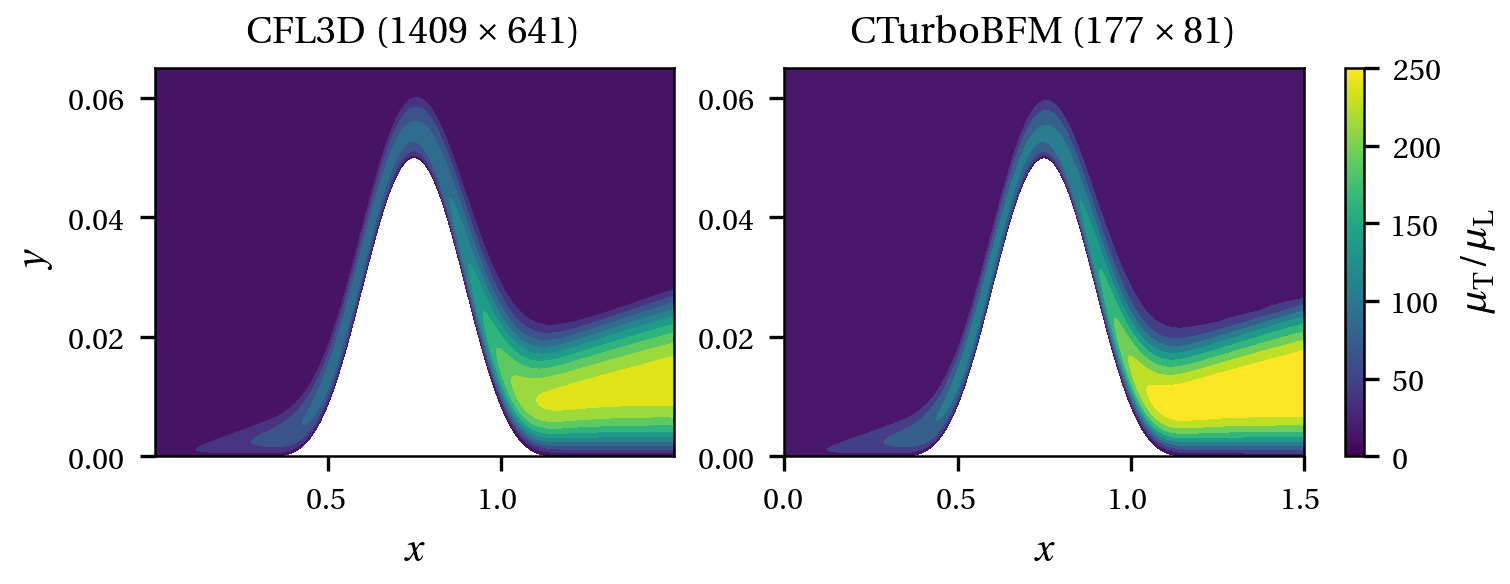

In [227]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm

# -----------------------------
# Figure setup
# -----------------------------
fig, ax = create_figure(fraction=1.0, aspect_ratio=1.3, subplots=(1, 2))

xmin = 0.0
xmax = 1.5
ymin = 0.0
ymax = 0.15

cmap = "viridis"
vmin = 0
vmax = 250
levels = np.linspace(vmin, vmax, 11)
norm = colors.Normalize(vmin=vmin, vmax=vmax)

# -----------------------------
# LEFT: NASA / reference
# -----------------------------
X = fields['X']
Y = fields['Y']
EV = fields['mut']

i_mask = np.any((X >= xmin) & (X <= xmax), axis=1)
j_mask = np.any((Y >= ymin) & (Y <= ymax), axis=0)

Xp = X[np.ix_(i_mask, j_mask)]
Yp = Y[np.ix_(i_mask, j_mask)]
mu_t = EV[np.ix_(i_mask, j_mask)]

c0 = ax[0].contourf(
    Xp, Yp, mu_t,
    levels=10,
    cmap=cmap,
    norm=norm,
)

# -----------------------------
# RIGHT: medium grid
# -----------------------------
data = datas[2]

X = data['x'][:, :, 0]
Y = data['y'][:, :, 0]
EV = data['Eddy Viscosity'][:, :, 0]

i_mask = np.any((X >= xmin) & (X <= xmax), axis=1)
j_mask = np.any((Y >= ymin) & (Y <= ymax), axis=0)

Xp = X[np.ix_(i_mask, j_mask)]
Yp = Y[np.ix_(i_mask, j_mask)]
mu_t2 = EV[np.ix_(i_mask, j_mask)]

c1 = ax[1].contourf(
    Xp, Yp, mu_t2/mu_ref,
    levels=10,
    cmap=cmap,
    norm=norm
)

# -----------------------------
# Common colorbar
# -----------------------------
cbar = fig.colorbar(
    cm.ScalarMappable(norm=norm, cmap=cmap),
    ax=ax[1],
    location='right',
    fraction=0.046,
    pad=0.04
)

cbar.set_label(r'$\mu_{\rm T} / \mu_{\rm L}$')

# -----------------------------
# Formatting
# -----------------------------
ax[0].set_ylim(ymin, 0.065)
ax[1].set_ylim(ymin, 0.065)

ax[0].set_xlabel(r'$x$')
ax[1].set_xlabel(r'$x$')
ax[0].set_ylabel(r'$y$')

ax[0].set_title(r"CFL3D ($1409 \times 641$)")
ax[1].set_title(r"CTurboBFM ($177 \times 81$)")


plt.savefig(
    f'nasa_bump_eddy_viscosity_comparison_reference.pdf',
)

